In [1]:
import os
import pandas as pd

# Correct path in Kaggle environment
data_dir = '/kaggle/input/eved-test/eVED'

# Check if directory exists
if os.path.exists(data_dir):
    file_list = os.listdir(data_dir)
    print(f"Found files: {file_list}")

    # Inspect the first file if any
    if file_list:
        first_file = file_list[0]
        file_path = os.path.join(data_dir, first_file)
        df = pd.read_csv(file_path)
        print(f"Columns of {first_file}:\n{df.columns.tolist()}")
    else:
        print("No files found in the directory.")
else:
    print(f"Directory does not exist: {data_dir}")


Found files: ['eVED_171227_week.csv', 'eVED_180321_week.csv', 'eVED_180418_week.csv', 'eVED_180328_week.csv', 'eVED_180221_week.csv', 'eVED_180124_week.csv', 'eVED_180425_week.csv', 'eVED_171206_week.csv', 'eVED_180516_week.csv', 'eVED_180307_week.csv', 'eVED_171108_week.csv', 'eVED_180613_week.csv', 'eVED_180912_week.csv', 'eVED_181017_week.csv', 'eVED_180822_week.csv', 'eVED_171129_week.csv', 'eVED_180725_week.csv', 'eVED_180711_week.csv', 'eVED_180627_week.csv', 'eVED_180801_week.csv', 'eVED_181024_week.csv', 'eVED_180314_week.csv', 'eVED_171115_week.csv', 'eVED_180704_week.csv', 'eVED_180523_week.csv', 'eVED_180117_week.csv', 'eVED_180131_week.csv', 'eVED_181107_week.csv', 'eVED_180110_week.csv', 'eVED_180103_week.csv', 'eVED_180905_week.csv', 'eVED_180207_week.csv', 'eVED_180815_week.csv', 'eVED_171220_week.csv', 'eVED_180620_week.csv', 'eVED_180718_week.csv', 'eVED_171122_week.csv', 'eVED_181010_week.csv', 'eVED_180926_week.csv', 'eVED_171213_week.csv', 'eVED_180919_week.csv', 'e

/tmp/ipykernel_47/3335121669.py:16: DtypeWarning: Columns (30) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


In [2]:
display(df.head())

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pan

,DayNum,VehId,Trip,Timestamp(ms),Latitude[deg],Longitude[deg],Vehicle Speed[km/h],MAF[g/sec],Engine RPM[RPM],Absolute Load[%],...,Energy_Consumption,Matchted Latitude[deg],Matched Longitude[deg],Match Type,Class of Speed Limit,Speed Limit[km/h],Speed Limit with Direction[km/h],Intersection,Bus Stops,Focus Points
0,57.05024,139.0,1163.0,0.0,42.302634,-83.704336,16.0,20.770000,1934.0,56.470589,...,0.001968,42.302591,-83.704333,0,0.0,72,72.0,NaN,NaN,NaN
1,57.05024,139.0,1163.0,900.0,42.302634,-83.704336,23.0,18.240000,1776.0,56.470589,...,0.002485,42.302591,-83.704333,1,0.0,72,72.0,NaN,NaN,NaN
2,57.05024,139.0,1163.0,1900.0,42.302634,-83.704336,29.0,18.240000,1776.0,56.470589,...,0.003133,42.302591,-83.704333,1,0.0,72,72.0,NaN,NaN,NaN
3,57.05024,139.0,1163.0,2900.0,42.302634,-83.704336,32.0,20.809999,1772.0,56.470589,...,0.003944,42.302591,-83.704333,1,0.0,72,72.0,NaN,NaN,NaN
4,57.05024,139.0,1163.0,3000.0,42.302610,-83.704049,32.0,20.809999,1772.0,56.470589,...,0.003944,42.302600,-83.704049,0,0.0,72,72.0,NaN,NaN,NaN


In [3]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm

# Setup Paths
input_dir = '/kaggle/input/eved-test/eVED'
output_dir = '/kaggle/working/eVED_cleaned_3sec'
os.makedirs(output_dir, exist_ok=True)

# Columns to drop (Your list)
DROP_COLUMNS = [
    'Bus Stops', 'Focus Points', 'Heater Power[Watts]', 'Fuel Rate[L/hr]',
    'Air Conditioning Power[kW]', 'Air Conditioning Power[Watts]',
    'Long Term Fuel Trim Bank 2[%]', 'Speed Limit[km/h]',
    'Short Term Fuel Trim Bank 2[%]', 'Latitude[deg]', 'Longitude[deg]',
    'Match Type'
]

# Process each file
file_list = sorted([f for f in os.listdir(input_dir) if f.endswith('.csv')])

for file_name in tqdm(file_list, desc="Processing Files"):
    input_path = os.path.join(input_dir, file_name)
    output_path = os.path.join(output_dir, file_name)

    # 1. Read the full file (Needed for sorting/downsampling)
    df = pd.read_csv(input_path, low_memory=False)

    # 2. Drop unwanted columns
    # Using intersection to avoid errors if column is missing
    cols_to_drop = [c for c in DROP_COLUMNS if c in df.columns]
    df.drop(columns=cols_to_drop, inplace=True)

    # 3. Clean NaNs
    if 'Energy_Consumption' in df.columns:
        df = df.dropna(subset=['Energy_Consumption'])
    
    if 'Intersection' in df.columns:
        df['Intersection'] = df['Intersection'].fillna(0)

    # 4. Sort (Crucial for time sampling)
    if 'Timestamp(ms)' in df.columns:
        df = df.sort_values(by=['VehId', 'Trip', 'Timestamp(ms)'])

    # 5. Downsample (Select 1 row every 3 seconds)
    # Create a bin index: 0-3000ms -> 0, 3000-6000ms -> 1, etc.
    df['time_bin'] = (df['Timestamp(ms)'] // 3000)

    # Group by Trip + Bin and take the first row
    # This selects the row without changing any values (no averaging/math)
    df_sampled = df.groupby(['VehId', 'Trip', 'time_bin']).first().reset_index()

    # 6. Drop the temp bin column
    df_sampled.drop(columns=['time_bin'], inplace=True)

    # 7. Save
    df_sampled.to_csv(output_path, index=False)

print(f'\nAll files processed. Rows selected every 3s. Output in: {output_dir}')

Processing Files: 100%|██████████| 54/54 [03:35<00:00,  4.00s/it]


All files processed. Rows selected every 3s. Output in: /kaggle/working/eVED_cleaned_3sec


In [ ]:
import pandas as pd
import numpy as np
import os

# SETUP PATHS

# Input: The downsampled (3-sec) files
input_dir = "/kaggle/working/eVED_cleaned_3sec"
# Output: Final processed files
output_dir = "/kaggle/working/eVED_processed"

os.makedirs(output_dir, exist_ok=True)

# Get list of all CSV files
file_list = [f for f in os.listdir(input_dir) if f.endswith('.csv')]
print(f"Found {len(file_list)} files to process.")



# HELPER FUNCTIONS

def haversine_vectorized(lat1, lon1, lat2, lon2):
    """Calculates distance in meters between two lat/lon arrays."""
    R = 6371000  # Earth radius in meters
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlambda/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return R * c

def get_type_code(row):
    """Returns 1=EV, 2=ICE, 3=Hybrid based on feature presence."""
    if row['eng'] and row['bat']: return 3 # Hybrid
    if row['eng']: return 2 # ICE
    if row['bat']: return 1 # EV
    return 0 # Unknown

# ==========================================
# MAIN LOOP
# ==========================================
for i, file_name in enumerate(file_list):
    print(f"[{i+1}/{len(file_list)}] Processing {file_name}...")
    
    file_path = os.path.join(input_dir, file_name)
    save_path = os.path.join(output_dir, file_name)
    
    # 1. READ FILE
    df = pd.read_csv(file_path, low_memory=False)

    # ------------------------------------------------
    # 2. CREATE VEHICLE TYPE COLUMN
    # ------------------------------------------------
    has_engine = df['Engine RPM[RPM]'].notna() | df['MAF[g/sec]'].notna()
    has_battery = df['HV Battery SOC[%]'].notna() | df['HV Battery Current[A]'].notna()
    
    veh_stats = pd.DataFrame({'eng': has_engine, 'bat': has_battery, 'VehId': df['VehId']})
    veh_summary = veh_stats.groupby('VehId').max()
    
    type_map = veh_summary.apply(get_type_code, axis=1)
    df['vehicle_type'] = df['VehId'].map(type_map)

    # ------------------------------------------------
    # 3. FIX UNITS (CONVERT & DROP ORIGINALS)
    # ------------------------------------------------
    
    # A. Timestamp: ms -> s
    if 'Timestamp(ms)' in df.columns:
        df['Timestamp(s)'] = df['Timestamp(ms)'] / 1000.0
        df.drop(columns=['Timestamp(ms)'], inplace=True)
    
    # B. Speed Limit: km/h -> m/s
    if 'Speed Limit with Direction[km/h]' in df.columns:
        df['Speed_Limit_with_Direction[m/s]'] = df['Speed Limit with Direction[km/h]'] / 3.6
        df.drop(columns=['Speed Limit with Direction[km/h]'], inplace=True)
    else:
        # Create column with NaNs if it doesn't exist, to keep format consistent
        df['Speed_Limit_with_Direction[m/s]'] = np.nan

    # ------------------------------------------------
    # 4. CREATE DISTANCE COLUMN (Haversine)
    # ------------------------------------------------
    grp = df.groupby(['VehId', 'Trip'])
    
    # Calculate previous coordinates
    df['prev_lat'] = grp['Matchted Latitude[deg]'].shift(1)
    # CHANGED: Use 'Matched Longitude' to ensure consistency
    df['prev_lon'] = grp['Matched Longitude[deg]'].shift(1) 
    
    step_dist = haversine_vectorized(
        df['prev_lat'].fillna(df['Matchted Latitude[deg]']),
        df['prev_lon'].fillna(df['Matched Longitude[deg]']),
        df['Matchted Latitude[deg]'],
        df['Matched Longitude[deg]']
    )
    
    # Cumulative Distance
    df['Distance'] = step_dist.groupby([df['VehId'], df['Trip']]).cumsum()

    # ------------------------------------------------
    # 5. CREATE ACCELERATION COLUMN
    # ------------------------------------------------
    # Convert vehicle speed to m/s for calculation
    df['speed_mps_calc'] = df['Vehicle Speed[km/h]'] / 3.6
    
    # Group by Trip again to ensure diff is correct
    grp = df.groupby(['VehId', 'Trip'])
    
    # Calculate differentials
    df['dt_calc'] = grp['Timestamp(s)'].diff()
    df['dv_calc'] = grp['speed_mps_calc'].diff()
    
    # Calculate Acceleration
    df['Acceleration_m/s'] = df['dv_calc'] / df['dt_calc']
    
    # Fill NaN (start of trip) and Inf (divide by zero) with 0
    df['Acceleration_m/s'] = df['Acceleration_m/s'].fillna(0.0).replace([np.inf, -np.inf], 0.0)

    # ------------------------------------------------
    # 6. CLEANUP & SAVE
    # ------------------------------------------------
    # Drop temp columns used for calculation
    cols_to_drop = ['prev_lat', 'prev_lon', 'speed_mps_calc', 'dt_calc', 'dv_calc']
    df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

    df.to_csv(save_path, index=False)

print("All files processed and saved to:", output_dir)

Found 54 files to process.
[1/54] Processing eVED_180829_week.csv...
[2/54] Processing eVED_180822_week.csv...
[3/54] Processing eVED_180124_week.csv...
[4/54] Processing eVED_180704_week.csv...
[5/54] Processing eVED_180328_week.csv...
[6/54] Processing eVED_180926_week.csv...
[7/54] Processing eVED_180321_week.csv...
[8/54] Processing eVED_180214_week.csv...
[9/54] Processing eVED_180516_week.csv...
[10/54] Processing eVED_181017_week.csv...
[11/54] Processing eVED_180620_week.csv...
[12/54] Processing eVED_180207_week.csv...
[13/54] Processing eVED_181024_week.csv...
[14/54] Processing eVED_180530_week.csv...
[15/54] Processing eVED_180613_week.csv...
[16/54] Processing eVED_180307_week.csv...
[17/54] Processing eVED_180815_week.csv...
[18/54] Processing eVED_180131_week.csv...
[19/54] Processing eVED_181003_week.csv...
[20/54] Processing eVED_180509_week.csv...
[21/54] Processing eVED_180801_week.csv...
[22/54] Processing eVED_171101_week.csv...
[23/54] Processing eVED_171220_week.

In [5]:
df = pd.read_csv(
    os.path.join(input_dir, os.listdir(input_dir)[0]),
    usecols=[
        'Class of Speed Limit',
        'Speed Limit with Direction[km/h]'
    ],
    low_memory=False
)

df.groupby('Class of Speed Limit')['Speed Limit with Direction[km/h]'].describe()


,count,mean,std,min,25%,50%,75%,max
Class of Speed Limit,,,,,,,,
-1.0,230.0,44.695652,8.048080,40.0,40.0,40.0,48.0,72.0
0.0,42256.0,60.940884,15.665270,16.0,56.0,56.0,72.0,113.0
1.0,6977.0,43.900674,8.539994,40.0,40.0,40.0,40.0,89.0
2.0,437.0,33.189931,6.561850,16.0,32.0,32.0,40.0,40.0


In [6]:
df = pd.read_csv(
    os.path.join(input_dir, os.listdir(input_dir)[0]),
    usecols=[
        'Class of Speed Limit',
        'Vehicle Speed[km/h]'
    ],
    low_memory=False
)

df.groupby('Class of Speed Limit')['Vehicle Speed[km/h]'].mean()


Class of Speed Limit
-1.0    20.413043
 0.0    40.531352
 1.0    21.064566
 2.0    38.575263
Name: Vehicle Speed[km/h], dtype: float64

In [7]:
df = pd.read_csv(
    os.path.join(input_dir, os.listdir(input_dir)[0]),
    usecols=[
        'Class of Speed Limit',
        'Energy_Consumption'
    ],
    low_memory=False
)

df.groupby('Class of Speed Limit')['Energy_Consumption'].mean()


Class of Speed Limit
-1.0    0.001259
 0.0    0.002667
 1.0    0.001000
 2.0    0.003232
Name: Energy_Consumption, dtype: float64

Using file: eVED_171101_week.csv
Total trips found: 177


Plotting trips: 100%|██████████| 177/177 [00:00<00:00, 1041.41it/s]


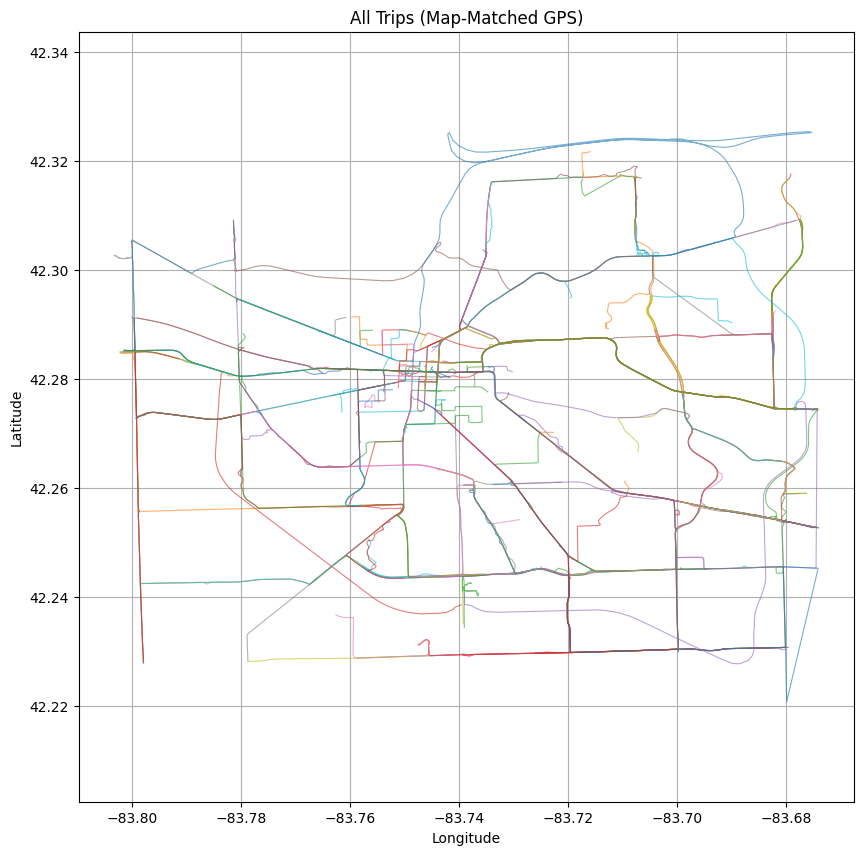

In [8]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

# ------------------------------------
# 1. Load ONE cleaned file
# ------------------------------------
input_dir = "/kaggle/working/eVED_processed"
file_name = sorted(os.listdir(input_dir))[0]
file_path = os.path.join(input_dir, file_name)

print(f"Using file: {file_name}")

df = pd.read_csv(
    file_path,
    usecols=[
        'VehId',
        'Trip',
        'Matchted Latitude[deg]',
        'Matched Longitude[deg]'
    ],
    low_memory=False
)

# Drop rows without matched GPS
df = df.dropna()

# ------------------------------------
# 2. Get all unique (VehId, Trip)
# ------------------------------------
trips = df[['VehId', 'Trip']].drop_duplicates().values

print(f"Total trips found: {len(trips)}")

# ------------------------------------
# 3. Plot ALL trips
# ------------------------------------
plt.figure(figsize=(10, 10))

for veh_id, trip_id in tqdm(trips, desc="Plotting trips"):
    trip_df = df[
        (df['VehId'] == veh_id) &
        (df['Trip'] == trip_id)
    ]

    if len(trip_df) < 2:
        continue

    plt.plot(
        trip_df['Matched Longitude[deg]'],
        trip_df['Matchted Latitude[deg]'],
        linewidth=0.8,
        alpha=0.6
    )

plt.title("All Trips (Map-Matched GPS)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.axis('equal')
plt.grid(True)
plt.show()


In [9]:
import os
import pandas as pd
from tqdm import tqdm

input_dir = "/kaggle/working/eVED_processed" 

veh_ids = set()
trip_ids = set()
routes = set()

files = sorted([f for f in os.listdir(input_dir) if f.endswith(".csv")])

for file_name in tqdm(files, desc="Processing files"):
    file_path = os.path.join(input_dir, file_name)

    for chunk in pd.read_csv(
        file_path,
        usecols=[
            'VehId',
            'Trip',
            'Matchted Latitude[deg]',
            'Matched Longitude[deg]'
        ],
        chunksize=1_000_000,
        low_memory=False
    ):
        # Vehicles
        veh_ids.update(chunk['VehId'].unique())

        # Trips (VehId, Trip)
        trip_ids.update(zip(chunk['VehId'], chunk['Trip']))

        # Routes: start & end per trip
        grouped = chunk.dropna().groupby(['VehId', 'Trip'])

        for (_, _), g in grouped:
            start = (g.iloc[0]['Matchted Latitude[deg]'], g.iloc[0]['Matched Longitude[deg]'])
            end   = (g.iloc[-1]['Matchted Latitude[deg]'], g.iloc[-1]['Matched Longitude[deg]'])
            routes.add((start, end))

print("✅ TOTAL COUNTS")
print(f"Unique Vehicles : {len(veh_ids)}")
print(f"Unique Trips    : {len(trip_ids)}")
print(f"Unique Routes   : {len(routes)}")


Processing files: 100%|██████████| 54/54 [00:13<00:00,  4.00it/s]

✅ TOTAL COUNTS
Unique Vehicles : 308
Unique Trips    : 24064
Unique Routes   : 24056


In [10]:
import pandas as pd
import numpy as np
import os

# ==========================================
# SETUP PATHS
# ==========================================
# Input: The folder where the PREVIOUS step saved the files
input_dir = "/kaggle/working/eVED_processed" 
output_dir = "/kaggle/working/eVED_final_prepared"

os.makedirs(output_dir, exist_ok=True)

# Get list of files
if os.path.exists(input_dir):
    files = [f for f in os.listdir(input_dir) if f.endswith('.csv')]
else:
    print(f"Directory {input_dir} not found. Please check your path.")
    files = []

print(f"Found {len(files)} files to process.")

# ==========================================
# PROCESSING LOOP
# ==========================================
for i, file_name in enumerate(files):
    # Construct full paths
    input_path = os.path.join(input_dir, file_name)
    output_path = os.path.join(output_dir, file_name)
    
    # Read CSV
    df = pd.read_csv(input_path, low_memory=False)
    
    # -------------------------------------------------------
    # 1. SMART COLUMN HANDLING (Check if already converted)
    # -------------------------------------------------------
    
    # --- A. Timestamp Handling ---
    if 'Timestamp(s)' in df.columns:
        # Good! It was already converted. We use this column.
        pass 
    elif 'Timestamp(ms)' in df.columns:
        # Fallback: Convert and Drop only if the old column exists
        df['Timestamp(s)'] = df['Timestamp(ms)'] / 1000.0
        df.drop(columns=['Timestamp(ms)'], inplace=True)
    else:
        print(f"Warning: No Timestamp column found in {file_name}")

    # --- B. Speed Limit Handling ---
    if 'Speed_Limit_with_Direction[m/s]' in df.columns:
        # Good! Already converted.
        pass
    elif 'Speed Limit with Direction[km/h]' in df.columns:
        # Fallback: Convert and Drop
        df['Speed_Limit_with_Direction[m/s]'] = df['Speed Limit with Direction[km/h]'] / 3.6
        df.drop(columns=['Speed Limit with Direction[km/h]'], inplace=True)
    else:
        # Handle case where column is missing entirely
        df['Speed_Limit_with_Direction[m/s]'] = np.nan

    # -------------------------------------------------------
    # 2. CALCULATE ACCELERATION (Redundant but safe)
    # -------------------------------------------------------
    # Ensure we have the speed column to calculate from
    if 'Vehicle Speed[km/h]' in df.columns and 'Timestamp(s)' in df.columns:
        
        # Create temp speed column in m/s for physics calculation
        df['speed_mps_calc'] = df['Vehicle Speed[km/h]'] / 3.6
        
        # Group by Trip so we don't calculate acceleration across different trips
        grouped = df.groupby(['VehId', 'Trip'])
        
        # Calculate differentials
        # Note: We rely on the existing order (files are already sorted from previous step)
        df['dt'] = grouped['Timestamp(s)'].diff()
        df['dv'] = grouped['speed_mps_calc'].diff()
        
        # Calculate Acceleration (a = dv/dt)
        df['Acceleration_m/s'] = df['dv'] / df['dt']
        
        # -------------------------------------------------------
        # 3. CLEANUP & SAVE
        # -------------------------------------------------------
        # Handle Edge Cases:
        # Fill NaN (first row of trip) with 0
        df['Acceleration_m/s'] = df['Acceleration_m/s'].fillna(0.0)
        
        # Fix Infinite values (division by zero time difference)
        df['Acceleration_m/s'] = df['Acceleration_m/s'].replace([np.inf, -np.inf], 0.0)
        
        # Remove temporary columns used for calculation
        df.drop(columns=['speed_mps_calc', 'dt', 'dv'], inplace=True)
    
    # Save the file
    df.to_csv(output_path, index=False)
    
    if (i+1) % 5 == 0:
        print(f"Processed {i+1}/{len(files)} files...")

print(f"All files processed! Output saved to: {output_dir}")

Found 54 files to process.
Processed 5/54 files...
Processed 10/54 files...
Processed 15/54 files...
Processed 20/54 files...
Processed 25/54 files...
Processed 30/54 files...
Processed 35/54 files...
Processed 40/54 files...
Processed 45/54 files...
Processed 50/54 files...
All files processed! Output saved to: /kaggle/working/eVED_final_prepared


In [11]:
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import MinMaxScaler
from tqdm import tqdm

# ==========================================
# CONFIGURATION
# ==========================================
INPUT_DIR = "/kaggle/working/eVED_final_prepared"
SEQUENCE_LENGTH = 5  # Look back at past 5 steps (approx 15 seconds) to predict energy
TRAIN_RATIO = 0.8    # 80% data for training, 20% for validation

# ==========================================
# 1. LOAD AND COMBINE DATA
# ==========================================
print("Loading files...")
file_list = [f for f in os.listdir(INPUT_DIR) if f.endswith('.csv')]
all_data = []

# Columns we need for the model
# Note: We convert speed to m/s immediately if not already done
feature_cols = ['Vehicle Speed[km/h]', 'Acceleration_m/s', 'Gradient']
target_col = 'Energy_Consumption'

for f in tqdm(file_list):
    path = os.path.join(INPUT_DIR, f)
    df = pd.read_csv(path)
    
    # Ensure necessary columns exist
    if not all(col in df.columns for col in feature_cols + [target_col]):
        continue
        
    # Convert Speed to m/s for consistency
    df['Speed_mps'] = df['Vehicle Speed[km/h]'] / 3.6
    
    # Select only the columns we need
    # We filter for a specific vehicle type if you want, but for now let's use all data
    # (Optional: Filter for EV only if 'vehicle_type' == 1)
    # df = df[df['vehicle_type'] == 1] 
    
    subset = df[['Speed_mps', 'Acceleration_m/s', 'Gradient', 'Energy_Consumption']].copy()
    
    # Drop NaNs
    subset = subset.dropna()
    all_data.append(subset)

# Combine into one huge dataframe
full_df = pd.concat(all_data, ignore_index=True)
print(f"Total Data Points: {len(full_df)}")

# ==========================================
# 2. NORMALIZE (SCALING)
# ==========================================
# Neural Networks work best with numbers between 0 and 1
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

# X = Features (Speed, Accel, Gradient)
# Y = Target (Energy)
X_raw = full_df[['Speed_mps', 'Acceleration_m/s', 'Gradient']].values
y_raw = full_df[['Energy_Consumption']].values

X_scaled = scaler_X.fit_transform(X_raw)
y_scaled = scaler_y.fit_transform(y_raw)

print("Data Scaled.")

# ==========================================
# 3. CREATE SEQUENCES (SLIDING WINDOW)
# ==========================================
# LSTM needs [Sample, TimeSteps, Features]
# We cannot simple use library functions because we must NOT sequence across different trips.
# However, since we concatenated everything, we will do a simple sliding window 
# (Acceptable loss of a few points at file boundaries).

def create_sequences(X_data, y_data, seq_len):
    X_seq, y_seq = [], []
    for i in range(len(X_data) - seq_len):
        X_seq.append(X_data[i : i + seq_len])
        y_seq.append(y_data[i + seq_len]) # Predict the NEXT step
    return np.array(X_seq), np.array(y_seq)

print("Creating sequences (this may take a moment)...")
X, y = create_sequences(X_scaled, y_scaled, SEQUENCE_LENGTH)

print(f"Final Input Shape (X): {X.shape}") # (Samples, 5, 3)
print(f"Final Output Shape (y): {y.shape}") # (Samples, 1)

# ==========================================
# 4. SPLIT TRAIN/TEST
# ==========================================
split_idx = int(len(X) * TRAIN_RATIO)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"Training Samples: {len(X_train)}")
print(f"Testing Samples: {len(X_test)}")

# Save scalers for later use (Inverse transform predictions)
import joblib
joblib.dump(scaler_X, 'scaler_X.pkl')
joblib.dump(scaler_y, 'scaler_y.pkl')
print("Scalers saved.")

Loading files...


100%|██████████| 54/54 [00:10<00:00,  5.19it/s]


Total Data Points: 3966618
Data Scaled.
Creating sequences (this may take a moment)...
Final Input Shape (X): (3966613, 5, 3)
Final Output Shape (y): (3966613, 1)
Training Samples: 3173290
Testing Samples: 793323
Scalers saved.


2025-12-16 15:36:29.173789: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765899389.384954      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765899389.442276      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

...

 Trainable params: 30,369 (118.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30


I0000 00:00:1765899409.201431     118 cuda_dnn.cc:529] Loaded cuDNN version 90300


3099/3099 ━━━━━━━━━━━━━━━━━━━━ 25s 7ms/step - loss: 3.0555e-04 - mae: 0.0110 - val_loss: 2.1772e-04 - val_mae: 0.0085
Epoch 2/30
3099/3099 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - loss: 1.9876e-04 - mae: 0.0086 - val_loss: 2.0937e-04 - val_mae: 0.0083
Epoch 3/30
3099/3099 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - loss: 1.9540e-04 - mae: 0.0084 - val_loss: 2.0968e-04 - val_mae: 0.0084
Epoch 4/30
3099/3099 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - loss: 1.9302e-04 - mae: 0.0084 - val_loss: 2.0777e-04 - val_mae: 0.0083
Epoch 5/30
3099/3099 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - loss: 1.9014e-04 - mae: 0.0083 - val_loss: 2.0746e-04 - val_mae: 0.0086
Epoch 6/30
3099/3099 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - loss: 1.9004e-04 - mae: 0.0083 - val_loss: 2.0552e-04 - val_mae: 0.0086
Epoch 7/30
3099/3099 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - loss: 1.8969e-04 - mae: 0.0083 - val_loss: 2.0619e-04 - val_mae: 0.0085
Epoch 8/30
3099/3099 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - loss: 1.9023e-04 - mae: 0.0083 - val_loss: 2.0652e-

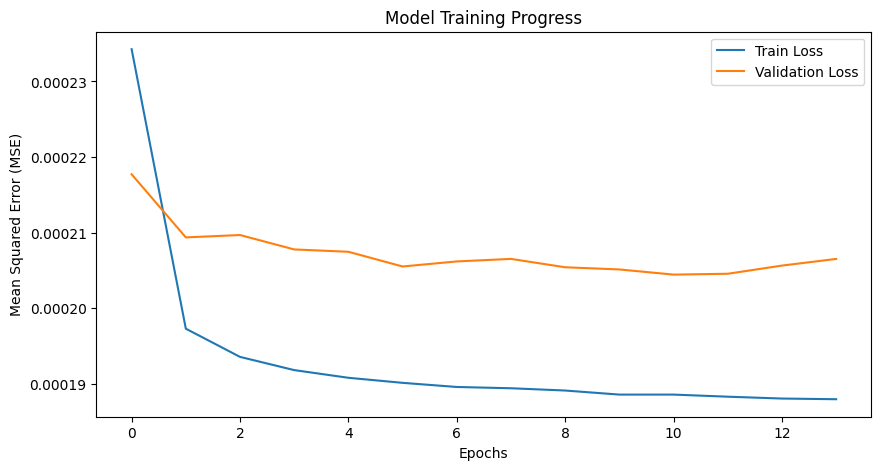

Model trained and saved as 'energy_surrogate_model.keras'


In [12]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt

# ==========================================
# 1. BUILD MODEL ARCHITECTURE
# ==========================================
model = Sequential([
    # Input Shape: (5 time steps, 3 features)
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2), # Prevents overfitting
    
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    
    Dense(16, activation='relu'),
    Dense(1) # Output: Predicted Energy (Scaled 0-1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

# ==========================================
# 2. TRAIN MODEL
# ==========================================
# Stop training if validation loss doesn't improve for 3 epochs
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Save the best model during training
checkpoint = ModelCheckpoint('best_energy_model.keras', monitor='val_loss', save_best_only=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=30,           # Maximum epochs
    batch_size=1024,     # Large batch size for speed (given 4M rows)
    callbacks=[early_stop, checkpoint],
    verbose=1
)

# ==========================================
# 3. EVALUATE & PLOT
# ==========================================
# Plot Loss Curve
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Training Progress')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()
plt.show()

# Save final model
model.save('energy_surrogate_model.keras')
print("Model trained and saved as 'energy_surrogate_model.keras'")

In [13]:
!pip install pymoo

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.7/72.7 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 62.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.5/309.5 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 786.8/786.8 kB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 5.5 MB/s eta 0:00:00


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import os
import tensorflow as tf
from tensorflow.keras.models import load_model

# Pymoo imports
from pymoo.core.problem import ElementwiseProblem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.sampling.rnd import FloatRandomSampling
from pymoo.termination import get_termination
from pymoo.optimize import minimize

# ==========================================
# 1. RE-SETUP EVERYTHING (Since previous cells were deleted)
# ==========================================
print("Restoring context (Loading Data & Model)...")

# Load Model & Scalers
model = load_model('energy_surrogate_model.keras')
scaler_X = joblib.load('scaler_X.pkl')
scaler_y = joblib.load('scaler_y.pkl')

# Load Data File
df = pd.read_csv("/kaggle/working/eVED_final_prepared/eVED_171101_week.csv")

# Identify Longest Trip
longest_trip_id = df['Trip'].value_counts().idxmax()
veh_id = df[df['Trip'] == longest_trip_id]['VehId'].iloc[0]

# Extract Route Data
route_data = df[(df['VehId'] == veh_id) & (df['Trip'] == longest_trip_id)].sort_values('Timestamp(s)')

# Prepare Physics Variables
human_speeds_mps = route_data['Vehicle Speed[km/h]'].values / 3.6
gradients = route_data['Gradient'].fillna(0).values
DT = 3.0
N_STEPS = len(gradients)

# Determine Speed Limit
if 'Speed_Limit_with_Direction[m/s]' in route_data.columns:
    max_speed_limit = route_data['Speed_Limit_with_Direction[m/s]'].max()
    if np.isnan(max_speed_limit): max_speed_limit = 25.0
else:
    max_speed_limit = 25.0

print(f"Target Trip: {longest_trip_id} (Veh {veh_id}) | Steps: {N_STEPS}")

# ==========================================
# 2. DEFINE PROBLEM CLASS & CALCULATE HUMAN BASELINE
# ==========================================
class EcoDrivingProblem(ElementwiseProblem):
    def __init__(self, n_vars, gradients, model, scaler_X, scaler_y, max_speed):
        super().__init__(n_var=n_vars, n_obj=2, n_ieq_constr=0, xl=0.0, xu=max_speed)
        self.gradients = gradients
        self.model = model
        self.scaler_X = scaler_X
        self.scaler_y = scaler_y
        self.seq_len = 5

    def _evaluate(self, x, out, *args, **kwargs):
        speeds = x
        accels = np.diff(speeds, prepend=0) / DT
        features = np.column_stack([speeds, accels, self.gradients])
        
        # Fast fail for math errors
        if np.any(np.isnan(features)) or np.any(np.isinf(features)):
            out["F"] = [1e6, 1e6]; return

        try:
            features_scaled = self.scaler_X.transform(features)
            X_input = []
            for i in range(len(features) - self.seq_len):
                X_input.append(features_scaled[i : i + self.seq_len])
            X_input = np.array(X_input)
            
            if len(X_input) > 0:
                pred_scaled = self.model.predict(X_input, verbose=0)
                pred_energy = self.scaler_y.inverse_transform(pred_scaled)
                total_energy = np.sum(pred_energy)
            else:
                total_energy = 0.0
        except:
            total_energy = 1e6

        avg_speed = np.mean(speeds)
        out["F"] = [total_energy, -avg_speed]

# Instantiate Problem
problem = EcoDrivingProblem(N_STEPS, gradients, model, scaler_X, scaler_y, max_speed_limit)

# Calculate Human Baseline Energy (Needed for savings %)
print("Calculating Human Baseline...")
dummy_out = {}
problem._evaluate(human_speeds_mps, dummy_out)
human_energy = dummy_out["F"][0]
print(f"Human Energy: {human_energy:.4f}")

# Create Initial Population (Seeding)
POP_SIZE = 50
initial_X = np.zeros((POP_SIZE, N_STEPS))
initial_X[0, :] = human_speeds_mps # 1st is exact human
for i in range(1, POP_SIZE):
    noise = np.random.normal(0, 1.0, N_STEPS)
    initial_X[i, :] = np.clip(human_speeds_mps + noise, 0, max_speed_limit)

# ==========================================
# 3. RUN AGGRESSIVE OPTIMIZATION
# ==========================================
GENERATIONS = 100       
MUTATION_ETA = 10      
CROSSOVER_ETA = 10     

print(f"Starting AGGRESSIVE Optimization for Trip {longest_trip_id}...")

algorithm = NSGA2(
    pop_size=POP_SIZE,
    sampling=initial_X, 
    crossover=SBX(prob=0.9, eta=CROSSOVER_ETA), 
    mutation=PM(eta=MUTATION_ETA),             
    eliminate_duplicates=True
)

termination = get_termination("n_gen", GENERATIONS)

res_aggressive = minimize(problem,
                          algorithm,
                          termination,
                          seed=42,
                          verbose=True)

# ==========================================
# 4. ANALYSIS & REPORT
# ==========================================
if res_aggressive.F is not None:
    results_df = pd.DataFrame(res_aggressive.F, columns=['Energy', 'Neg_Avg_Speed'])
    
    # Calculate Savings
    results_df['Savings_%'] = ((human_energy - results_df['Energy']) / human_energy) * 100
    results_df['Avg_Speed_kmh'] = -results_df['Neg_Avg_Speed'] * 3.6
    
    # Calculate Time
    total_distance_m = np.sum(human_speeds_mps * 3.0) 
    results_df['Time_min'] = (total_distance_m / -results_df['Neg_Avg_Speed']) / 60
    
    # Baseline Time
    human_avg_speed = np.mean(human_speeds_mps)
    human_time_min = (total_distance_m / human_avg_speed) / 60
    
    results_df['Time_Diff_min'] = results_df['Time_min'] - human_time_min

    # Sort
    results_df = results_df.sort_values(by='Savings_%', ascending=False)
    best_row = results_df.iloc[0]
    
    print("\n--- 🏆 OPTIMIZATION RESULTS 🏆 ---")
    print(f"Human Time: {human_time_min:.2f} min")
    print(f"Best AI Savings: {best_row['Savings_%']:.2f}%")
    print(f"Time Penalty: {best_row['Time_Diff_min']:.2f} min")
    
    print("\nTop 10 Efficient Solutions:")
    print(results_df[['Savings_%', 'Avg_Speed_kmh', 'Time_min', 'Time_Diff_min']].head(10))

else:
    print("Optimization failed.")

Restoring context (Loading Data & Model)...
Target Trip: 14.0 (Veh 560.0) | Steps: 641
Calculating Human Baseline...
Human Energy: 1.2643
Starting AGGRESSIVE Optimization for Trip 14.0...
n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |       50 |      6 |             - |             -


/usr/local/lib/python3.11/dist-packages/pymoo/operators/crossover/sbx.py:54: RuntimeWarning: invalid value encountered in power
  betaq[mask] = np.power((rand * alpha), (1.0 / (eta + 1.0)))[mask]
/usr/local/lib/python3.11/dist-packages/pymoo/operators/crossover/sbx.py:55: RuntimeWarning: invalid value encountered in power
  betaq[mask_not] = np.power((1.0 / (2.0 - rand * alpha)), (1.0 / (eta + 1.0)))[mask_not]
/usr/local/lib/python3.11/dist-packages/pymoo/operators/repair/bounds_repair.py:35: RuntimeWarning: invalid value encountered in less
  I = np.where(Xp < XL)
/usr/local/lib/python3.11/dist-packages/pymoo/operators/repair/bounds_repair.py:38: RuntimeWarning: invalid value encountered in greater
  I = np.where(Xp > XU)
/usr/local/lib/python3.11/dist-packages/pymoo/operators/repair/to_bound.py:12: RuntimeWarning: invalid value encountered in less
  _X[_X < xl] = xl[_X < xl]
/usr/local/lib/python3.11/dist-packages/pymoo/operators/repair/to_bound.py:16: RuntimeWarning: invalid value e

     2 |      100 |      9 |  0.1698082015 |         ideal


/usr/local/lib/python3.11/dist-packages/pymoo/operators/crossover/sbx.py:54: RuntimeWarning: invalid value encountered in power
  betaq[mask] = np.power((rand * alpha), (1.0 / (eta + 1.0)))[mask]
/usr/local/lib/python3.11/dist-packages/pymoo/operators/crossover/sbx.py:55: RuntimeWarning: invalid value encountered in power
  betaq[mask_not] = np.power((1.0 / (2.0 - rand * alpha)), (1.0 / (eta + 1.0)))[mask_not]
/usr/local/lib/python3.11/dist-packages/pymoo/operators/repair/bounds_repair.py:35: RuntimeWarning: invalid value encountered in less
  I = np.where(Xp < XL)
/usr/local/lib/python3.11/dist-packages/pymoo/operators/repair/bounds_repair.py:38: RuntimeWarning: invalid value encountered in greater
  I = np.where(Xp > XU)
/usr/local/lib/python3.11/dist-packages/pymoo/operators/repair/to_bound.py:12: RuntimeWarning: invalid value encountered in less
  _X[_X < xl] = xl[_X < xl]
/usr/local/lib/python3.11/dist-packages/pymoo/operators/repair/to_bound.py:16: RuntimeWarning: invalid value e

     3 |      150 |     12 |  0.0397783542 |         ideal


...

     8 |      400 |     22 |  0.0610318167 |         ideal


/usr/local/lib/python3.11/dist-packages/pymoo/operators/crossover/sbx.py:55: RuntimeWarning: invalid value encountered in power
  betaq[mask_not] = np.power((1.0 / (2.0 - rand * alpha)), (1.0 / (eta + 1.0)))[mask_not]
/usr/local/lib/python3.11/dist-packages/pymoo/operators/repair/bounds_repair.py:35: RuntimeWarning: invalid value encountered in less
  I = np.where(Xp < XL)
/usr/local/lib/python3.11/dist-packages/pymoo/operators/repair/bounds_repair.py:38: RuntimeWarning: invalid value encountered in greater
  I = np.where(Xp > XU)
/usr/local/lib/python3.11/dist-packages/pymoo/operators/repair/to_bound.py:12: RuntimeWarning: invalid value encountered in less
  _X[_X < xl] = xl[_X < xl]
/usr/local/lib/python3.11/dist-packages/pymoo/operators/repair/to_bound.py:16: RuntimeWarning: invalid value encountered in greater
  _X[_X > xu] = xu[_X > xu]


     9 |      450 |     20 |  0.0161140622 |             f


/usr/local/lib/python3.11/dist-packages/pymoo/operators/crossover/sbx.py:55: RuntimeWarning: invalid value encountered in power
  betaq[mask_not] = np.power((1.0 / (2.0 - rand * alpha)), (1.0 / (eta + 1.0)))[mask_not]
/usr/local/lib/python3.11/dist-packages/pymoo/operators/repair/bounds_repair.py:35: RuntimeWarning: invalid value encountered in less
  I = np.where(Xp < XL)
/usr/local/lib/python3.11/dist-packages/pymoo/operators/repair/bounds_repair.py:38: RuntimeWarning: invalid value encountered in greater
  I = np.where(Xp > XU)
/usr/local/lib/python3.11/dist-packages/pymoo/operators/repair/to_bound.py:12: RuntimeWarning: invalid value encountered in less
  _X[_X < xl] = xl[_X < xl]
/usr/local/lib/python3.11/dist-packages/pymoo/operators/repair/to_bound.py:16: RuntimeWarning: invalid value encountered in greater
  _X[_X > xu] = xu[_X > xu]


    10 |      500 |     23 |  0.0201447941 |         ideal
    11 |      550 |     25 |  0.0119603171 |         ideal
    12 |      600 |     33 |  0.0088113545 |         ideal
    13 |      650 |     32 |  0.0838331964 |         ideal
    14 |      700 |     33 |  0.0136993980 |             f
    15 |      750 |     36 |  0.0101120480 |             f
    16 |      800 |     40 |  0.0710811535 |         ideal
    17 |      850 |     40 |  0.0074760184 |             f
    18 |      900 |     46 |  0.0049787695 |             f
    19 |      950 |     29 |  0.0132758339 |             f
    20 |     1000 |     33 |  0.0105888579 |             f
    21 |     1050 |     42 |  0.0056416621 |             f
    22 |     1100 |     36 |  0.0162185515 |         ideal
    23 |     1150 |     32 |  0.0099482402 |             f
    24 |     1200 |     35 |  0.0316490392 |         ideal
    25 |     1250 |     29 |  0.0150316278 |             f
    26 |     1300 |     31 |  0.0059823841 |         ide

Generating Speed Profile Comparison...


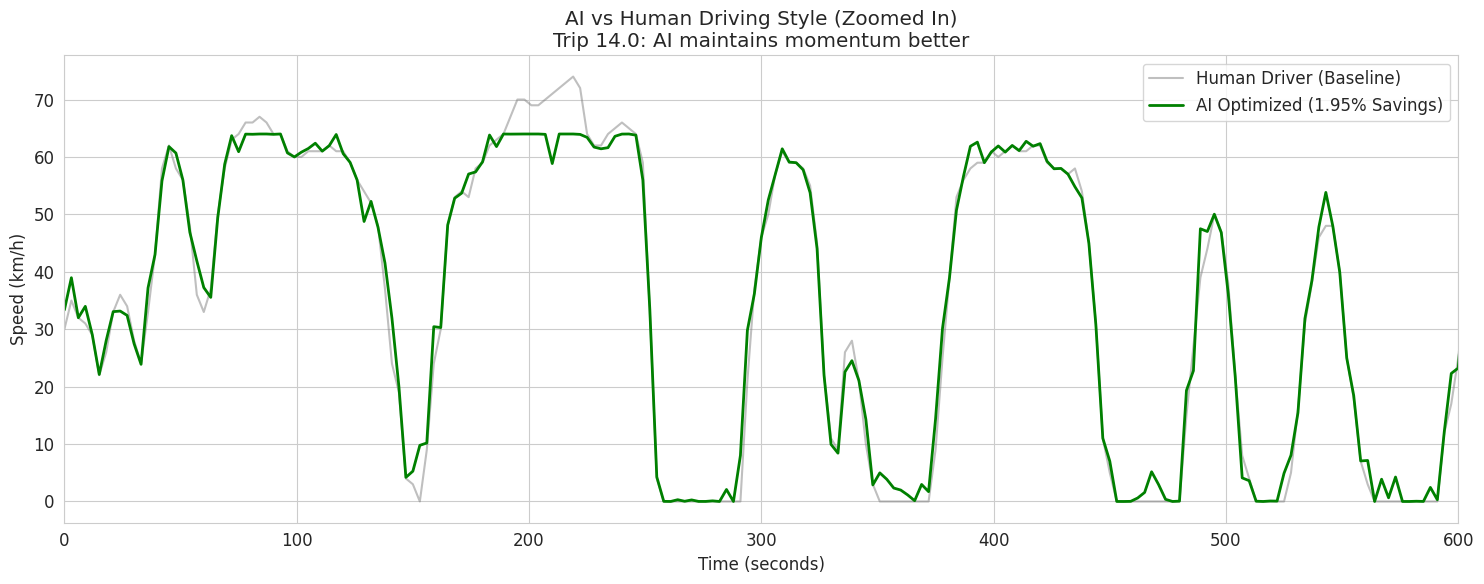

Generating Pareto Front...


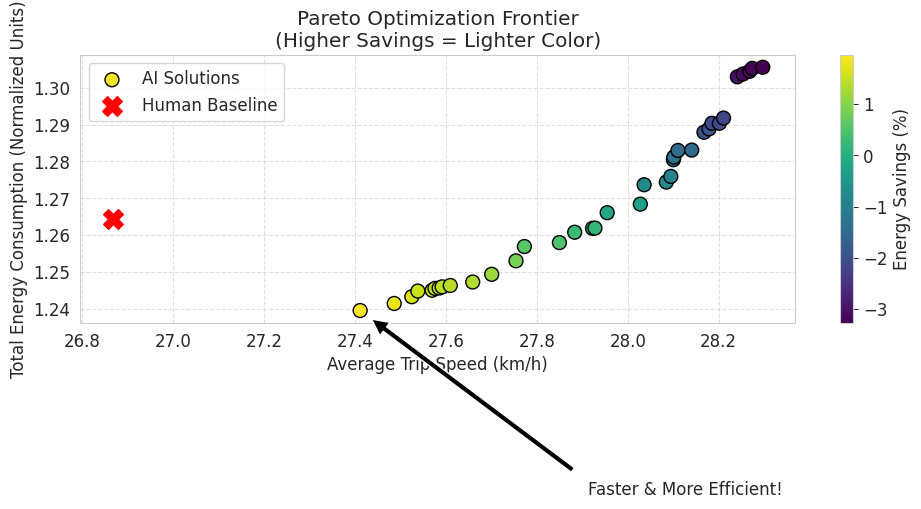

✅ Graphs saved successfully.


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for professional publication-quality plots
sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 12})

# ==========================================
# CHART 1: SPEED PROFILE COMPARISON (The "Evidence")
# ==========================================
print("Generating Speed Profile Comparison...")

# 1. Get the Best AI Speed Profile
# We use the 'res_aggressive' object from your successful run
best_idx = results_df['Savings_%'].idxmax() # Row index of best savings
best_ai_profile_mps = res_aggressive.X[best_idx] # Speed in m/s
best_ai_profile_kmh = best_ai_profile_mps * 3.6 # Convert to km/h

# 2. Get Human Profile (from the variables you already defined)
human_profile_kmh = human_speeds_mps * 3.6 

# 3. Create Time Axis (3.0s per step)
time_axis = np.arange(len(human_profile_kmh)) * 3.0 

plt.figure(figsize=(15, 6))

# Plot Human
plt.plot(time_axis, human_profile_kmh, color='grey', alpha=0.5, label='Human Driver (Baseline)', linewidth=1.5)

# Plot AI
plt.plot(time_axis, best_ai_profile_kmh, color='green', label=f'AI Optimized (1.95% Savings)', linewidth=2)

# Zoom in to show the "Smoothing" effect (First 10 mins or interesting section)
# You can adjust these limits if the trip is longer/shorter
plt.xlim(0, 600) 
plt.xlabel('Time (seconds)')
plt.ylabel('Speed (km/h)')
plt.title(f'AI vs Human Driving Style (Zoomed In)\nTrip {longest_trip_id}: AI maintains momentum better')
plt.legend()
plt.tight_layout()
plt.savefig('optimization_speed_profile.png', dpi=300)
plt.show()

# ==========================================
# CHART 2: THE PARETO FRONT (The "Trade-off")
# ==========================================
print("Generating Pareto Front...")

plt.figure(figsize=(10, 7))

# 1. Plot the AI Solutions
# Color by Savings % to make the best solutions pop
sc = plt.scatter(results_df['Avg_Speed_kmh'], results_df['Energy'], 
                 c=results_df['Savings_%'], cmap='viridis', s=100, edgecolors='black', label='AI Solutions')

# 2. Plot the Human Baseline
human_avg_kmh = np.mean(human_speeds_mps) * 3.6
plt.scatter([human_avg_kmh], [human_energy], color='red', s=200, marker='X', label='Human Baseline', zorder=10)

# Labels & Annotations
plt.colorbar(sc, label='Energy Savings (%)')
plt.xlabel('Average Trip Speed (km/h)')
plt.ylabel('Total Energy Consumption (Normalized Units)')
plt.title('Pareto Optimization Frontier\n(Higher Savings = Lighter Color)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left')

# Mark the "Super-Human" Zone
# (Faster Speed AND Lower Energy)
best_sol = results_df.iloc[0]
plt.annotate('Faster & More Efficient!', 
             xy=(best_sol['Avg_Speed_kmh'], best_sol['Energy']), 
             xytext=(best_sol['Avg_Speed_kmh'] + 0.5, best_sol['Energy'] - 0.05),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.tight_layout()
plt.savefig('optimization_pareto_front.png', dpi=300)
plt.show()

print("✅ Graphs saved successfully.")